In [1]:
# ===== Compare baseline (A,B,C order) vs shuffle (C,B,A) per model =====
# - Extracts A/B/C choices from baseline CSVs (e.g., gpt4o_test.csv)
# - Extracts A/B/C choices from corresponding shuffle CSVs (*_shuffle_test.csv)
# - Compares paired marginal distributions with Stuart-Maxwell tests per model
# - Runs paired McNemar tests per model on (A vs C) and (B vs C) using exact binomial
# - Applies Benjamini-Hochberg (BH) FDR correction within each test family
#
# Outputs (in ./out/shuffle_vs_baseline/):
#   - baseline_counts.csv, shuffle_counts.csv
#   - stuart_maxwell_baseline_vs_shuffle.csv
#   - order_robustness_results_table.csv
#   - mcnemar_AC.csv, mcnemar_BC.csv
#
# NOTE: Assumes each CSV has columns: scenario_code, answer (e.g., "B - reason...")

import os, re
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import chi2, binomtest

# ------------ CONFIG ------------
MODEL_FILES = [
    "gemma3-27b_test.csv",
    "gpt4o_test.csv",
    "llama3.1_test.csv",
    "qwen2.5-32b_test.csv",
]

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "LLM Normal Test").exists() and (candidate / "LLM Shuffle Test").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root with LLM Normal Test and LLM Shuffle Test directories.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
NORMAL_DIR = REPO_ROOT / "LLM Normal Test"
SHUFFLE_DIR = REPO_ROOT / "LLM Shuffle Test"
ANALYSIS_DIR = REPO_ROOT / "Analyses" / "Shuffle vs. Normal Analysis"
OUT_DIR = ANALYSIS_DIR / "out" / "shuffle_vs_baseline"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------ HELPERS ------------
def model_from_path(path: str) -> str:
    return re.sub(r"_test\.csv$", "", os.path.basename(path))

def shuffle_path_for_baseline(path: str) -> str:
    # e.g., "gpt4o_test.csv" -> "gpt4o_shuffle_test.csv"
    return re.sub(r"_test\.csv$", "_shuffle_test.csv", path)

def robust_read_csv(path: str) -> pd.DataFrame:
    for enc in ("utf-8", "utf-8-sig", "latin1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            pass
    return pd.read_csv(path)

def extract_choice_letter(ans: str) -> str | None:
    """Return 'A','B','C' from 'Answer: B - ...' or 'C - ...' or 'A'."""
    if not isinstance(ans, str) or not ans.strip():
        return None
    s = re.sub(r'^\s*Answer:\s*', '', ans, flags=re.IGNORECASE).strip()
    m = re.match(r'^\s*([ABC])\b', s, flags=re.IGNORECASE)
    if not m:
        m = re.search(r'\b([ABC])\b', s[:80], flags=re.IGNORECASE)
    return m.group(1).upper() if m else None

def count_choices(df: pd.DataFrame) -> dict:
    ch = df["answer"].map(extract_choice_letter).dropna()
    vc = ch.value_counts()
    A = int(vc.get("A", 0)); B = int(vc.get("B", 0)); C = int(vc.get("C", 0))
    tot = int(ch.shape[0])
    return {
        "A": A, "B": B, "C": C, "total": tot,
        "pct_A": round(100*A/tot, 2) if tot else 0.0,
        "pct_B": round(100*B/tot, 2) if tot else 0.0,
        "pct_C": round(100*C/tot, 2) if tot else 0.0,
        "valid_rows": tot,
        "invalid_rows": int(len(df) - tot),
    }

def bh_fdr(pvals: list[float]) -> list[float]:
    """Benjamini–Hochberg q-values."""
    if not pvals:
        return []
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = np.empty(m, dtype=float)
    cum_min = 1.0
    for i, idx in enumerate(order[::-1], start=1):
        rank = m - i + 1
        q = pvals[idx] * m / rank
        cum_min = min(cum_min, q)
        ranked[idx] = cum_min
    return ranked.tolist()

# McNemar exact via binomial on discordant pairs (b vs c)
def mcnemar_exact(b: int, c: int) -> float:
    n = b + c
    if n == 0:
        return 1.0
    res = binomtest(min(b, c), n=n, p=0.5, alternative="two-sided")
    return float(res.pvalue)

# ------------ LOAD & SUMMARIZE COUNTS ------------
baseline_rows, shuffle_rows = [], []
paired_data = {}  # model -> DataFrame with baseline & shuffle choices per scenario

for model_file in MODEL_FILES:
    model = model_from_path(model_file)
    base_path = NORMAL_DIR / model_file
    shuffle_path = SHUFFLE_DIR / shuffle_path_for_baseline(model_file)

    if not base_path.exists():
        print(f"[WARN] Missing baseline for {model}: {base_path}")
        continue
    if not shuffle_path.exists():
        print(f"[WARN] Missing shuffle for {model}: {shuffle_path}")
        continue

    df_base = robust_read_csv(base_path)
    df_shuf = robust_read_csv(shuffle_path)

    # Summaries
    base_stats = count_choices(df_base)
    shuf_stats = count_choices(df_shuf)

    baseline_rows.append({"model": model, **base_stats, "source": base_path.name})
    shuffle_rows.append({"model": model, **shuf_stats, "source": shuffle_path.name})

    # Pair by scenario_code for paired tests
    if "scenario_code" not in df_base.columns or "scenario_code" not in df_shuf.columns:
        print(f"[WARN] {model}: missing 'scenario_code' in one of the files; skipping paired tests.")
        continue

    a_base = df_base[["scenario_code", "answer"]].copy()
    a_shuf = df_shuf[["scenario_code", "answer"]].copy()
    a_base["choice_base"] = a_base["answer"].map(extract_choice_letter)
    a_shuf["choice_shuf"] = a_shuf["answer"].map(extract_choice_letter)
    del a_base["answer"]; del a_shuf["answer"]

    merged = pd.merge(a_base, a_shuf, on="scenario_code", how="inner")
    paired_data[model] = merged.dropna(subset=["choice_base", "choice_shuf"]).reset_index(drop=True)

# Save counts
df_base_counts = pd.DataFrame(baseline_rows).sort_values("model")
df_shuf_counts = pd.DataFrame(shuffle_rows).sort_values("model")
df_base_counts.to_csv(OUT_DIR / "baseline_counts.csv", index=False)
df_shuf_counts.to_csv(OUT_DIR / "shuffle_counts.csv", index=False)

print("\n=== Baseline counts ===")
print(df_base_counts[["model","A","B","C","total","pct_A","pct_B","pct_C","invalid_rows"]].to_string(index=False))
print("\n=== Shuffle counts ===")
print(df_shuf_counts[["model","A","B","C","total","pct_A","pct_B","pct_C","invalid_rows"]].to_string(index=False))

# ------------ STUART-MAXWELL (paired marginal homogeneity) per model ------------
CHOICE_LABELS = ["A", "B", "C"]

def transition_table(df_paired: pd.DataFrame) -> pd.DataFrame:
    return pd.crosstab(df_paired["choice_base"], df_paired["choice_shuf"]).reindex(
        index=CHOICE_LABELS, columns=CHOICE_LABELS, fill_value=0
    )

def stuart_maxwell_test(table: pd.DataFrame):
    counts = table.to_numpy(dtype=float)
    k = counts.shape[0]
    row_totals = counts.sum(axis=1)
    col_totals = counts.sum(axis=0)
    d = row_totals[:-1] - col_totals[:-1]
    v = np.zeros((k - 1, k - 1), dtype=float)
    for i in range(k - 1):
        for j in range(k - 1):
            if i == j:
                v[i, i] = row_totals[i] + col_totals[i] - 2 * counts[i, i]
            else:
                v[i, j] = -(counts[i, j] + counts[j, i])
    statistic = float(d @ np.linalg.pinv(v) @ d)
    dof = k - 1
    p_value = float(chi2.sf(statistic, dof))
    return statistic, dof, p_value

sm_rows, sm_pvals = [], []
for model, df_pair in paired_data.items():
    table = transition_table(df_pair)
    statistic, dof, p_value = stuart_maxwell_test(table)
    base_counts = table.sum(axis=1).astype(int)
    shuf_counts = table.sum(axis=0).astype(int)
    sm_rows.append({
        "model": model,
        "statistic": round(float(statistic), 4),
        "dof": int(dof),
        "p_value": float(p_value),
        "baseline_counts": f"{base_counts['A']}/{base_counts['B']}/{base_counts['C']}",
        "shuffle_counts": f"{shuf_counts['A']}/{shuf_counts['B']}/{shuf_counts['C']}",
        "N_pairs": int(table.to_numpy().sum()),
        "A_to_B": int(table.loc["A", "B"]),
        "A_to_C": int(table.loc["A", "C"]),
        "B_to_A": int(table.loc["B", "A"]),
        "B_to_C": int(table.loc["B", "C"]),
        "C_to_A": int(table.loc["C", "A"]),
        "C_to_B": int(table.loc["C", "B"]),
    })
    sm_pvals.append(float(p_value))

# BH-correct Stuart-Maxwell p-values across the four models
if sm_pvals:
    sm_q = bh_fdr(sm_pvals)
    for i in range(len(sm_rows)):
        sm_rows[i]["q_value_BH"] = float(sm_q[i])
        sm_rows[i]["significant_BH_0.05"] = bool(sm_q[i] < 0.05)

df_sm = pd.DataFrame(sm_rows).sort_values("model")
df_sm.to_csv(OUT_DIR / "stuart_maxwell_baseline_vs_shuffle.csv", index=False)
df_sm.to_csv(OUT_DIR / "order_robustness_results_table.csv", index=False)

print("\n=== Stuart-Maxwell: baseline vs shuffle (paired A/B/C marginal homogeneity) ===")
print(df_sm[["model","statistic","dof","p_value","q_value_BH","significant_BH_0.05","baseline_counts","shuffle_counts","N_pairs","B_to_C","C_to_B"]]
      .to_string(index=False))

# ------------ MCNEMAR (paired) for A vs C and B vs C ------------
def mcnemar_from_paired(df_paired: pd.DataFrame, pos_label: str, neg_label: str):
    """
    McNemar for two-category comparison (e.g., C vs A).
    Keeps only pairs where BOTH baseline and shuffle are in {pos_label, neg_label}.
    Returns b (#base=neg,shuffle=pos), c (#base=pos,shuffle=neg), N_kept, p_exact
    """
    filt = df_paired[
        df_paired["choice_base"].isin([pos_label, neg_label]) &
        df_paired["choice_shuf"].isin([pos_label, neg_label])
    ].copy()
    if filt.empty:
        return 0, 0, 0, 1.0
    base_pos = (filt["choice_base"] == pos_label)
    shuf_pos = (filt["choice_shuf"] == pos_label)
    # McNemar off-diagonals:
    b = int((~base_pos & shuf_pos).sum())  # base=neg, shuf=pos
    c = int((base_pos & ~shuf_pos).sum())  # base=pos, shuf=neg)
    p = mcnemar_exact(b, c)
    return b, c, int(filt.shape[0]), p

mcnemar_AC_rows, pvals_AC = [], []
mcnemar_BC_rows, pvals_BC = [], []

for model, df_pair in paired_data.items():
    # A vs C: pos=C, neg=A
    b_AC, c_AC, n_AC, p_AC = mcnemar_from_paired(df_pair, pos_label="C", neg_label="A")
    mcnemar_AC_rows.append({
        "model": model, "b_(A->C)": b_AC, "c_(C->A)": c_AC,
        "N_pairs_kept": n_AC, "p_value_exact": p_AC
    })
    pvals_AC.append(p_AC)
    # B vs C: pos=C, neg=B
    b_BC, c_BC, n_BC, p_BC = mcnemar_from_paired(df_pair, pos_label="C", neg_label="B")
    mcnemar_BC_rows.append({
        "model": model, "b_(B->C)": b_BC, "c_(C->B)": c_BC,
        "N_pairs_kept": n_BC, "p_value_exact": p_BC
    })
    pvals_BC.append(p_BC)

# BH-correct within each family
if pvals_AC:
    q_AC = bh_fdr(pvals_AC)
    for i in range(len(mcnemar_AC_rows)):
        mcnemar_AC_rows[i]["q_value_BH"] = float(q_AC[i])

if pvals_BC:
    q_BC = bh_fdr(pvals_BC)
    for i in range(len(mcnemar_BC_rows)):
        mcnemar_BC_rows[i]["q_value_BH"] = float(q_BC[i])

df_AC = pd.DataFrame(mcnemar_AC_rows).sort_values("model")
df_BC = pd.DataFrame(mcnemar_BC_rows).sort_values("model")
df_AC.to_csv(OUT_DIR / "mcnemar_AC.csv", index=False)
df_BC.to_csv(OUT_DIR / "mcnemar_BC.csv", index=False)

print("\n=== McNemar (paired) A vs C (kept only pairs in {A,C}) ===")
print(df_AC.to_string(index=False))
print("\n=== McNemar (paired) B vs C (kept only pairs in {B,C}) ===")
print(df_BC.to_string(index=False))



=== Baseline counts ===
      model  A  B  C  total  pct_A  pct_B  pct_C  invalid_rows
 gemma3-27b 14 22 84    120  11.67  18.33  70.00             0
      gpt4o 13 24 83    120  10.83  20.00  69.17             0
   llama3.1 15 45 60    120  12.50  37.50  50.00             0
qwen2.5-32b 14 30 76    120  11.67  25.00  63.33             0

=== Shuffle counts ===
      model  A  B  C  total  pct_A  pct_B  pct_C  invalid_rows
 gemma3-27b 14 28 78    120  11.67  23.33  65.00             0
      gpt4o 15 21 84    120  12.50  17.50  70.00             0
   llama3.1 16 29 75    120  13.33  24.17  62.50             0
qwen2.5-32b 12 31 77    120  10.00  25.83  64.17             0

=== Stuart-Maxwell: baseline vs shuffle (paired A/B/C marginal homogeneity) ===
      model  statistic  dof  p_value  q_value_BH  significant_BH_0.05 baseline_counts shuffle_counts  N_pairs  B_to_C  C_to_B
 gemma3-27b     3.6000    2 0.165299    0.330598                False        14/22/84       14/28/78      120     

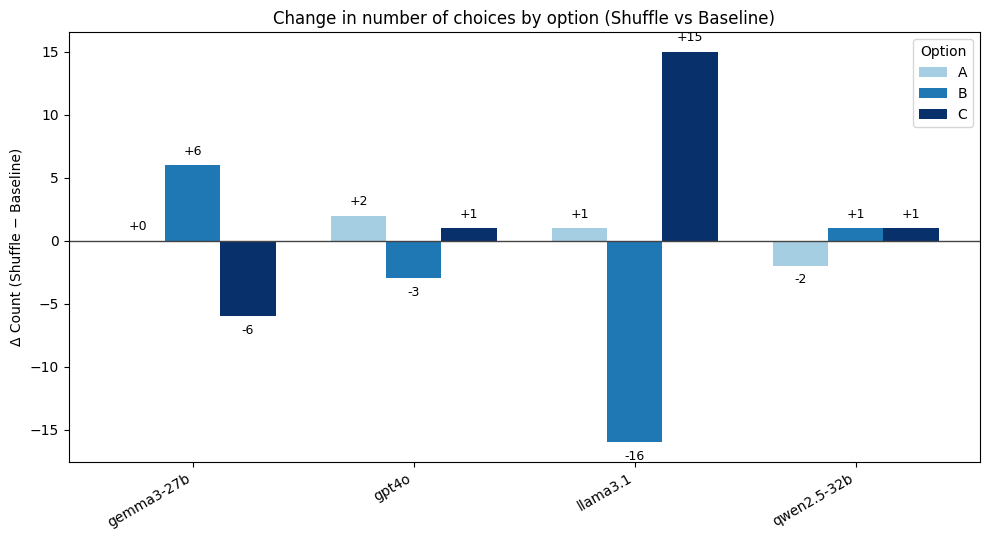

[OK] Saved figure to out\shuffle_vs_baseline\delta_counts_by_option.png


In [2]:
# ===== Plot Δ counts (Shuffle − Baseline) of A/B/C choices per model in one graph =====
# Tries to read precomputed counts from:
#   out/shuffle_vs_baseline/baseline_counts.csv
#   out/shuffle_vs_baseline/shuffle_counts.csv
# If not found, it will compute counts from raw files:
#   baseline_files = ["gemma3-27b_test.csv", "gpt4o_test.csv", "llama3.1_test.csv", "qwen2.5-32b_test.csv"]
#   and their paired "*_shuffle_test.csv".
#
# Output figure:
#   out/shuffle_vs_baseline/delta_counts_by_option.png
#
# Bars are colored in shades of blue: A = light, B = medium, C = dark.

import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = os.path.join("out", "shuffle_vs_baseline")
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Try to load precomputed counts ----------
base_counts_path = os.path.join(OUT_DIR, "baseline_counts.csv")
shuf_counts_path = os.path.join(OUT_DIR, "shuffle_counts.csv")

def extract_choice_letter(ans: str) -> str | None:
    if not isinstance(ans, str) or not ans.strip():
        return None
    s = re.sub(r'^\s*Answer:\s*', '', ans, flags=re.IGNORECASE).strip()
    m = re.match(r'^\s*([ABC])\b', s, flags=re.IGNORECASE)
    if not m:
        m = re.search(r'\b([ABC])\b', s[:80], flags=re.IGNORECASE)
    return m.group(1).upper() if m else None

def model_from_path(path: str) -> str:
    return re.sub(r"_test\.csv$", "", os.path.basename(path))

def shuffle_path_for_baseline(path: str) -> str:
    return re.sub(r"_test\.csv$", "_shuffle_test.csv", path)

def count_from_raw(files_baseline: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows_base, rows_shuf = [], []
    for base_path in files_baseline:
        model = model_from_path(base_path)
        shuf_path = shuffle_path_for_baseline(base_path)
        if not (os.path.exists(base_path) and os.path.exists(shuf_path)):
            print(f"[WARN] Missing pair for {model}: {base_path} / {shuf_path}")
            continue
        df_b = pd.read_csv(base_path)
        df_s = pd.read_csv(shuf_path)
        ch_b = df_b["answer"].map(extract_choice_letter).dropna()
        ch_s = df_s["answer"].map(extract_choice_letter).dropna()
        vc_b = ch_b.value_counts()
        vc_s = ch_s.value_counts()
        rows_base.append({"model": model, "A": int(vc_b.get("A",0)), "B": int(vc_b.get("B",0)), "C": int(vc_b.get("C",0)), "total": int(ch_b.shape[0])})
        rows_shuf.append({"model": model, "A": int(vc_s.get("A",0)), "B": int(vc_s.get("B",0)), "C": int(vc_s.get("C",0)), "total": int(ch_s.shape[0])})
    return pd.DataFrame(rows_base).sort_values("model"), pd.DataFrame(rows_shuf).sort_values("model")

if os.path.exists(base_counts_path) and os.path.exists(shuf_counts_path):
    df_base = pd.read_csv(base_counts_path)
    df_shuf = pd.read_csv(shuf_counts_path)
else:
    baseline_files = [
        "gemma3-27b_test.csv",
        "gpt4o_test.csv",
        "llama3.1_test.csv",
        "qwen2.5-32b_test.csv",
    ]
    df_base, df_shuf = count_from_raw(baseline_files)

# Align and compute differences
merged = pd.merge(df_base, df_shuf, on="model", suffixes=("_base","_shuf"))
for opt in ["A","B","C"]:
    merged[f"Δ{opt}"] = merged[f"{opt}_shuf"] - merged[f"{opt}_base"]

models = merged["model"].tolist()
x = np.arange(len(models))
width = 0.25

# Colors: A light, B medium, C dark (all blue shades)
color_A = "#a6cee3"
color_B = "#1f78b4"
color_C = "#08306b"

plt.figure(figsize=(10, 5.5))
bars_A = plt.bar(x - width, merged["ΔA"], width, label="A", color=color_A)
bars_B = plt.bar(x,           merged["ΔB"], width, label="B", color=color_B)
bars_C = plt.bar(x + width,   merged["ΔC"], width, label="C", color=color_C)

# Zero line
plt.axhline(0, color="#444444", linewidth=1)

# Labels & ticks
plt.xticks(x, models, rotation=30, ha="right")
plt.ylabel("Δ Count (Shuffle − Baseline)")
plt.title("Change in number of choices by option (Shuffle vs Baseline)")

# Annotate bars with values
def annotate(bars):
    for b in bars:
        h = b.get_height()
        if np.isnan(h): continue
        y = h + (0.6 if h >= 0 else -0.6)
        plt.text(b.get_x() + b.get_width()/2.0, y, f"{int(h):+d}", ha="center", va="bottom" if h>=0 else "top", fontsize=9)

annotate(bars_A); annotate(bars_B); annotate(bars_C)

plt.legend(title="Option")
plt.tight_layout()
out_path = os.path.join(OUT_DIR, "delta_counts_by_option.png")
plt.savefig(out_path, dpi=200)
plt.show()
print(f"[OK] Saved figure to {out_path}")


In [3]:
# Save the Shuffle−Baseline Δ counts plot as a PDF
# Reads:
#   out/shuffle_vs_baseline/baseline_counts.csv
#   out/shuffle_vs_baseline/shuffle_counts.csv
# Falls back to raw files if needed.

import os, re
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "pdf.fonttype": 42,  # embed TrueType (vector text)
    "ps.fonttype": 42
})

OUT_DIR = os.path.join("out", "shuffle_vs_baseline")
os.makedirs(OUT_DIR, exist_ok=True)

base_counts_path = os.path.join(OUT_DIR, "baseline_counts.csv")
shuf_counts_path = os.path.join(OUT_DIR, "shuffle_counts.csv")

def extract_choice_letter(ans: str):
    if not isinstance(ans, str) or not ans.strip():
        return None
    s = re.sub(r'^\s*Answer:\s*', '', ans, flags=re.IGNORECASE).strip()
    m = re.match(r'^\s*([ABC])\b', s, flags=re.IGNORECASE) or re.search(r'\b([ABC])\b', s[:80], flags=re.IGNORECASE)
    return m.group(1).upper() if m else None

def model_from_path(path: str) -> str:
    return re.sub(r"_test\.csv$", "", os.path.basename(path))

def shuffle_path_for_baseline(path: str) -> str:
    return re.sub(r"_test\.csv$", "_shuffle_test.csv", path)

def count_from_raw(files_baseline):
    rows_base, rows_shuf = [], []
    for base_path in files_baseline:
        model = model_from_path(base_path)
        shuf_path = shuffle_path_for_baseline(base_path)
        if not (os.path.exists(base_path) and os.path.exists(shuf_path)):
            continue
        df_b = pd.read_csv(base_path)
        df_s = pd.read_csv(shuf_path)
        ch_b = df_b["answer"].map(extract_choice_letter).dropna()
        ch_s = df_s["answer"].map(extract_choice_letter).dropna()
        vc_b, vc_s = ch_b.value_counts(), ch_s.value_counts()
        rows_base.append({"model": model, "A": int(vc_b.get("A",0)), "B": int(vc_b.get("B",0)), "C": int(vc_b.get("C",0)), "total": int(ch_b.shape[0])})
        rows_shuf.append({"model": model, "A": int(vc_s.get("A",0)), "B": int(vc_s.get("B",0)), "C": int(vc_s.get("C",0)), "total": int(ch_s.shape[0])})
    return pd.DataFrame(rows_base).sort_values("model"), pd.DataFrame(rows_shuf).sort_values("model")

if os.path.exists(base_counts_path) and os.path.exists(shuf_counts_path):
    df_base = pd.read_csv(base_counts_path)
    df_shuf = pd.read_csv(shuf_counts_path)
else:
    baseline_files = [
        "gemma3-27b_test.csv",
        "gpt4o_test.csv",
        "llama3.1_test.csv",
        "qwen2.5-32b_test.csv",
    ]
    df_base, df_shuf = count_from_raw(baseline_files)

merged = pd.merge(df_base, df_shuf, on="model", suffixes=("_base","_shuf"))
for opt in ["A","B","C"]:
    merged[f"Δ{opt}"] = merged[f"{opt}_shuf"] - merged[f"{opt}_base"]

models = merged["model"].tolist()
x = np.arange(len(models))
width = 0.25
color_A, color_B, color_C = "#a6cee3", "#1f78b4", "#08306b"  # light→dark blue

plt.figure(figsize=(10, 5.5))
bars_A = plt.bar(x - width, merged["ΔA"], width, label="A", color=color_A)
bars_B = plt.bar(x,           merged["ΔB"], width, label="B", color=color_B)
bars_C = plt.bar(x + width,   merged["ΔC"], width, label="C", color=color_C)
plt.axhline(0, color="#444444", linewidth=1)
plt.xticks(x, models, rotation=30, ha="right")
plt.ylabel("Δ Count (Shuffle − Baseline)")
plt.title("Change in number of choices by option (Shuffle vs Baseline)")
plt.legend(title="Option")
plt.tight_layout()

pdf_path = os.path.join(OUT_DIR, "delta_counts_by_option.pdf")
plt.savefig(pdf_path)  # vector PDF
plt.close()
print(f"[OK] Saved PDF to {pdf_path}")


[OK] Saved PDF to out\shuffle_vs_baseline\delta_counts_by_option.pdf


In [4]:
# ===== Order effects as dumbbell charts (percentages) — clearer than Δ bars =====
# Reads:
#   out/shuffle_vs_baseline/baseline_counts.csv
#   out/shuffle_vs_baseline/shuffle_counts.csv
# Falls back to raw CSVs if needed:
#   ["gemma3-27b_test.csv","gpt4o_test.csv","llama3.1_test.csv","qwen2.5-32b_test.csv"]
#
# Output:
#   out/shuffle_vs_baseline/order_effects_dumbbell_by_option.pdf

import os, re
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

OUT_DIR = os.path.join("out", "shuffle_vs_baseline")
os.makedirs(OUT_DIR, exist_ok=True)

base_counts_path = os.path.join(OUT_DIR, "baseline_counts.csv")
shuf_counts_path = os.path.join(OUT_DIR, "shuffle_counts.csv")

# ---- helpers (only used if we must recompute counts from raw) ----
def extract_choice_letter(ans: str):
    if not isinstance(ans, str) or not ans.strip(): return None
    s = re.sub(r'^\s*Answer:\s*', '', ans, flags=re.IGNORECASE).strip()
    m = re.match(r'^\s*([ABC])\b', s, flags=re.IGNORECASE) or re.search(r'\b([ABC])\b', s[:80], flags=re.IGNORECASE)
    return m.group(1).upper() if m else None

def model_from_path(p: str) -> str:
    return re.sub(r"_test\.csv$", "", os.path.basename(p))

def shuffle_path_for_baseline(p: str) -> str:
    return re.sub(r"_test\.csv$", "_shuffle_test.csv", p)

def count_from_raw(files_baseline):
    rows_b, rows_s = [], []
    for base_path in files_baseline:
        model = model_from_path(base_path)
        shuf_path = shuffle_path_for_baseline(base_path)
        if not (os.path.exists(base_path) and os.path.exists(shuf_path)):
            print(f"[WARN] Missing pair for {model}")
            continue
        b = pd.read_csv(base_path)
        s = pd.read_csv(shuf_path)
        cb = b["answer"].map(extract_choice_letter).dropna().value_counts()
        cs = s["answer"].map(extract_choice_letter).dropna().value_counts()
        rows_b.append({"model": model, "A": int(cb.get("A",0)), "B": int(cb.get("B",0)), "C": int(cb.get("C",0)), "total": int(cb.sum())})
        rows_s.append({"model": model, "A": int(cs.get("A",0)), "B": int(cs.get("B",0)), "C": int(cs.get("C",0)), "total": int(cs.sum())})
    return pd.DataFrame(rows_b).sort_values("model"), pd.DataFrame(rows_s).sort_values("model")

# ---- load counts ----
if os.path.exists(base_counts_path) and os.path.exists(shuf_counts_path):
    df_base = pd.read_csv(base_counts_path)
    df_shuf = pd.read_csv(shuf_counts_path)
else:
    baseline_files = [
        "gemma3-27b_test.csv",
        "gpt4o_test.csv",
        "llama3.1_test.csv",
        "qwen2.5-32b_test.csv",
    ]
    df_base, df_shuf = count_from_raw(baseline_files)

# Compute percents
keep_cols = ["model","A","B","C","total"]
df_base = df_base[keep_cols].copy()
df_shuf = df_shuf[keep_cols].copy()
for df in (df_base, df_shuf):
    for opt in ["A","B","C"]:
        df[f"pct_{opt}"] = (100.0 * df[opt] / df["total"]).round(2)

# Merge baseline vs shuffle
merged = pd.merge(df_base[["model","pct_A","pct_B","pct_C"]],
                  df_shuf[["model","pct_A","pct_B","pct_C"]],
                  on="model", suffixes=("_base","_shuf")).sort_values("model")

# Colors (A light → C dark)
COLORS = {"A": "#a6cee3", "B": "#1f78b4", "C": "#08306b"}

# ---- plot dumbbells: three horizontal panels (A/B/C) ----
fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.2), sharey=True)
models = merged["model"].tolist()
ypos = np.arange(len(models))[::-1]  # top-to-bottom order

for ax, opt in zip(axes, ["A","B","C"]):
    left  = merged[f"pct_{opt}_base"].to_numpy()
    right = merged[f"pct_{opt}_shuf"].to_numpy()
    delta = right - left

    # connecting lines
    for y, l, r in zip(ypos, left, right):
        ax.plot([l, r], [y, y], color=COLORS[opt], linewidth=2, alpha=0.9)

    # baseline hollow, shuffle filled
    ax.scatter(left,  ypos, s=50, facecolors="none", edgecolors=COLORS[opt], linewidths=2, label="Baseline" if opt=="A" else None)
    ax.scatter(right, ypos, s=50, facecolors=COLORS[opt], edgecolors=COLORS[opt], linewidths=1, label="Shuffle"  if opt=="A" else None)

    # Δ labels at the shuffle end
    for y, r, d in zip(ypos, right, delta):
        ax.text(r + (0.8 if d>=0 else -0.8), y,
                f"{d:+.2f} pp", va="center",
                ha="left" if d>=0 else "right",
                fontsize=9, color=COLORS[opt])

    ax.set_title(f"Option {opt}", color=COLORS[opt], pad=8)
    ax.set_xlabel("Share of choices (%)")
    ax.grid(axis="x", linestyle=":", alpha=0.5)
    ax.set_xlim(0, 100)

axes[0].set_yticks(ypos)
axes[0].set_yticklabels(models)
axes[0].legend(loc="lower left", frameon=False)
fig.suptitle("Baseline (hollow) vs Shuffle (filled): share of A/B/C choices by model", y=0.98)
plt.tight_layout(rect=[0,0,1,0.95])

out_pdf = os.path.join(OUT_DIR, "order_effects_dumbbell_by_option.pdf")
plt.savefig(out_pdf)
plt.close()
print(f"[OK] Saved PDF: {out_pdf}")


[OK] Saved PDF: out\shuffle_vs_baseline\order_effects_dumbbell_by_option.pdf


In [5]:
# ===== Order effects as Δ percentage bars =====
# Each panel shows Δ% (Shuffle − Baseline) for A, B, or C, centered at zero.
# Bars are shaded from light blue (A) to dark blue (C).
#
# Output: out/shuffle_vs_baseline/order_effects_delta_percent.pdf

import os, pandas as pd, numpy as np, matplotlib.pyplot as plt

OUT_DIR = "out/shuffle_vs_baseline"
os.makedirs(OUT_DIR, exist_ok=True)

# Load counts
df_base = pd.read_csv(os.path.join(OUT_DIR,"baseline_counts.csv"))
df_shuf = pd.read_csv(os.path.join(OUT_DIR,"shuffle_counts.csv"))

# Compute % deltas
merged = pd.merge(df_base[["model","A","B","C","total"]],
                  df_shuf[["model","A","B","C","total"]],
                  on="model", suffixes=("_base","_shuf")).sort_values("model")

for opt in ["A","B","C"]:
    merged[f"pct_{opt}_base"] = 100*merged[f"{opt}_base"]/merged["total_base"]
    merged[f"pct_{opt}_shuf"] = 100*merged[f"{opt}_shuf"]/merged["total_shuf"]
    merged[f"Δ{opt}"] = merged[f"pct_{opt}_shuf"] - merged[f"pct_{opt}_base"]

models = merged["model"].tolist()
y = np.arange(len(models))

colors = {"A":"#a6cee3", "B":"#1f78b4", "C":"#08306b"}

fig, axes = plt.subplots(1,3, figsize=(12,4), sharey=True)

for ax,opt in zip(axes,["A","B","C"]):
    vals = merged[f"Δ{opt}"]
    ax.barh(y, vals, color=colors[opt])
    for yi,v in zip(y,vals):
        ax.text(v + (0.5 if v>=0 else -0.5), yi, f"{v:+.1f}pp",
                va="center", ha="left" if v>=0 else "right", fontsize=9, color="black")
    ax.axvline(0, color="gray", lw=1)
    ax.set_title(f"Δ% Option {opt}", color=colors[opt])
    ax.set_xlabel("Change (pp)")

axes[0].set_yticks(y)
axes[0].set_yticklabels(models)
plt.tight_layout()

outpath = os.path.join(OUT_DIR,"order_effects_delta_percent.pdf")
plt.savefig(outpath)
plt.close()
print(f"[OK] Saved {outpath}")


[OK] Saved out/shuffle_vs_baseline\order_effects_delta_percent.pdf
